In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

DAY = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
DELAY_CATEGORY = ["Early (< -5 min)", "On-time (-5–0 min)", "Minor (1–15 min)", "Moderate (16–60 min)", "Severe (> 60 min)"]
DELAY_CATEGORY_COLORS = ["#2196F3", "#4CAF50", "#FFC107", "#FF9800", "#F44336"]
df = pd.read_csv("Cleaned_Airline_Data.csv")

In [16]:
df["Day"] = pd.Categorical(df["DayOfWeek"].map(dict(enumerate(DAY))),categories=DAY, ordered=True)
df[["DayOfWeek", "ARR_DELAY"]].describe().round(2)

,DayOfWeek,ARR_DELAY
count,1200874.00,1200874.00
mean,2.93,0.54
std,1.91,42.66
min,0.00,-96.00
25%,1.00,-16.00
50%,3.00,-8.00
75%,4.00,3.00
max,6.00,1843.00


In [17]:
summary = (df.groupby("Day", observed=True)[["ARR_DELAY"]].agg(["mean", "median", "std"]).round(2))
summary.columns = ["ARR mean (min)", "ARR median (min)", "ARR std"]
summary


,ARR mean (min),ARR median (min),ARR std
Day,,,
Mon,1.20,-8.0,42.51
Tue,1.90,-9.0,47.03
Wed,-0.69,-9.0,39.29
Thu,0.59,-8.0,42.51
Fri,1.92,-7.0,45.26
Sat,0.76,-8.0,44.17
Sun,-1.91,-9.0,37.52


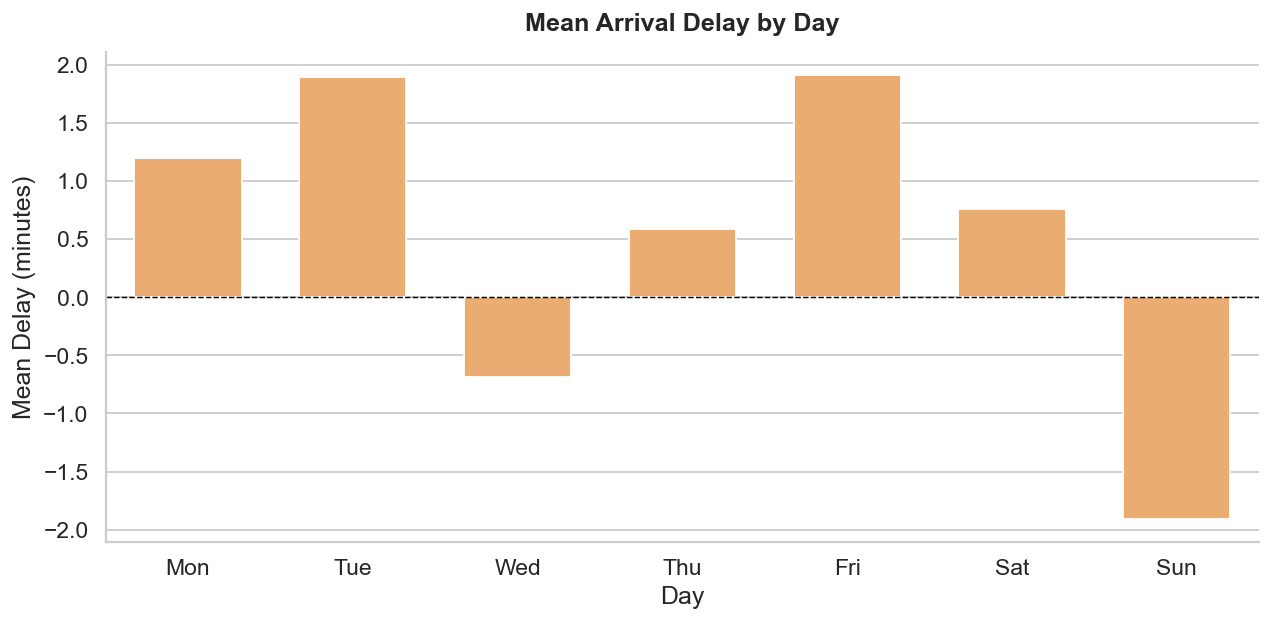

In [26]:
day_means = (df.groupby("Day", observed=True)[["ARR_DELAY"]].mean().reset_index())

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=day_means, x="Day", y="ARR_DELAY", color="#FFAB5D", ax=ax, width=0.65)

ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_title("Mean Arrival Delay by Day", fontsize=14, fontweight="bold")
ax.set_xlabel("Day")
ax.set_ylabel("Mean Delay (minutes)")
sns.despine()
plt.tight_layout()
plt.show()


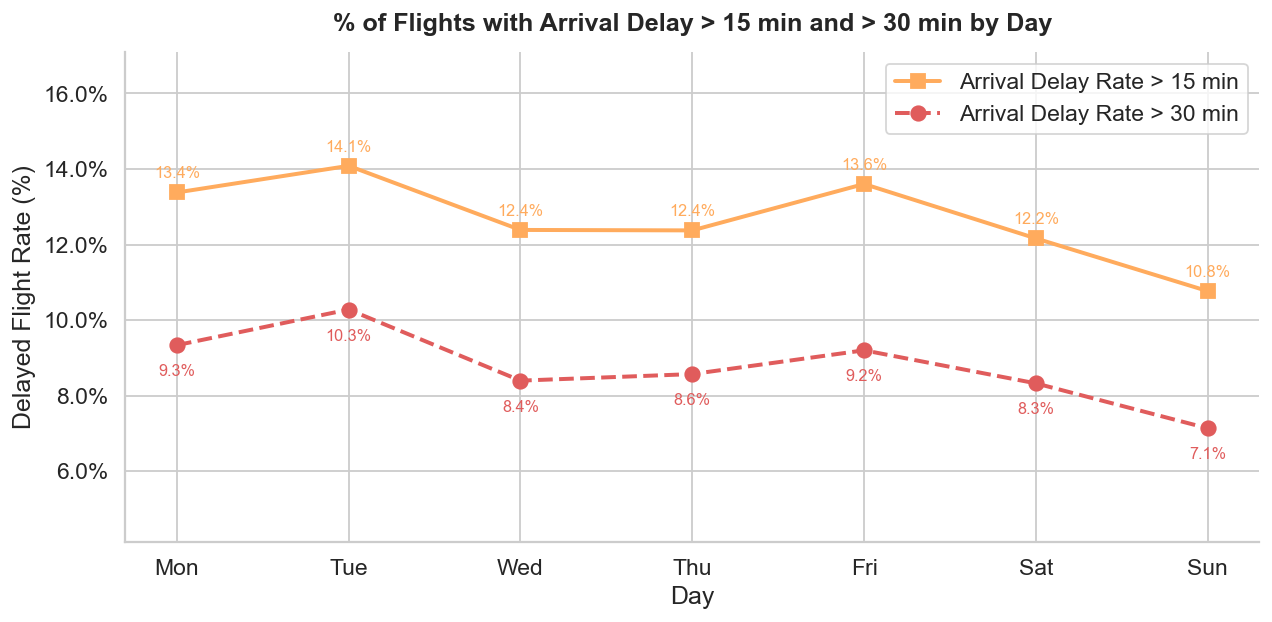

In [27]:
rate = df.groupby("Day", observed=True).agg(
    rate_15=("ARR_DELAY", lambda x: (x > 15).mean() * 100),
    rate_30=("ARR_DELAY", lambda x: (x > 30).mean() * 100),
).reset_index()

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(rate["Day"], rate["rate_15"], marker="s", linewidth=2.2, markersize=8,
        color="#FFAB5D", label="Arrival Delay Rate > 15 min")
ax.plot(rate["Day"], rate["rate_30"], marker="o", linewidth=2.2, markersize=8,
        color="#E05C5C", linestyle="--", label="Arrival Delay Rate > 30 min")

for _, row in rate.iterrows():
    ax.text(row["Day"], row["rate_15"] + 0.3, f"{row['rate_15']:.1f}%",
            ha="center", va="bottom", fontsize=9, color="#FFAB5D")
    ax.text(row["Day"], row["rate_30"] - 0.5, f"{row['rate_30']:.1f}%",
            ha="center", va="top", fontsize=9, color="#E05C5C")

ax.set_title("% of Flights with Arrival Delay > 15 min and > 30 min by Day", fontsize=14, fontweight="bold")
ax.set_xlabel("Day")
ax.set_ylabel("Delayed Flight Rate (%)")
ax.legend()
ax.yaxis.set_major_formatter(mticker.PercentFormatter(decimals=1))
y_min = rate[["rate_15", "rate_30"]].min().min()
y_max = rate[["rate_15", "rate_30"]].max().max()
ax.set_ylim(y_min - 3, y_max + 3)
sns.despine()
plt.tight_layout()
plt.show()


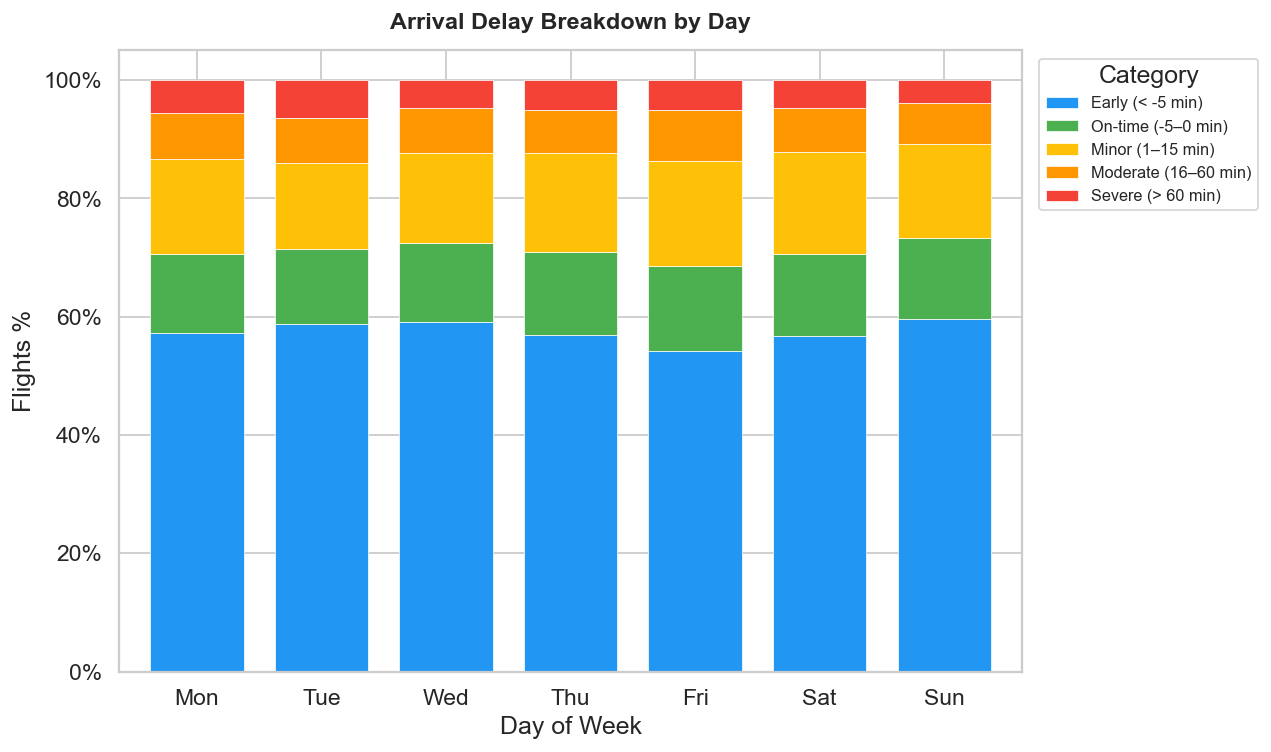

In [28]:
def delay_category(minutes):
    if minutes < -5:
        return "Early (< -5 min)"
    elif minutes <= 0:
        return "On-time (-5–0 min)"
    elif minutes <= 15:
        return "Minor (1–15 min)"
    elif minutes <= 60:
        return "Moderate (16–60 min)"
    else:
        return "Severe (> 60 min)"

fig, ax = plt.subplots(figsize=(10, 6))

tmp = df.copy()
tmp["Category"] = tmp["ARR_DELAY"].apply(delay_category)
tmp["Category"] = pd.Categorical(tmp["Category"], categories=DELAY_CATEGORY, ordered=True)

pct = (tmp.groupby(["Day", "Category"], observed=True).size().unstack("Category", fill_value=0).div(tmp.groupby("Day", observed=True).size(), axis=0).mul(100))

pct[DELAY_CATEGORY].plot(kind="bar", stacked=True, ax=ax, color=DELAY_CATEGORY_COLORS, width=0.75, edgecolor="white", linewidth=0.4)

ax.set_title("Arrival Delay Breakdown by Day", fontsize=13, fontweight="bold")
ax.set_xlabel("Day of Week")
ax.set_ylabel("Flights %")
ax.set_xticklabels(DAY, rotation=0)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))
ax.legend(title="Category", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()